# Resnet Bayesien

In [1]:
import torch
import torchvision
import numpy as np
from torchvision.transforms import v2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

### Fonctions usuelles

In [2]:
def predictive_entropy(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        return -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
    return -np.sum(output * np.log(output + 1e-10), axis=-1)

def mutual_information(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        entropy = -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
        expected_entropy = -np.mean(np.sum(output * np.log(output + 1e-10), axis=-1), axis=0)
        return entropy - expected_entropy
    return np.zeros(output.shape[0], dtype=float)

### Hyperparamètres

In [3]:
lr = 0.001
epochs = 50
batch_size = 128
milestones = [20, 35, 45]
gamma = 0.5
num_monte_carlo = 1

### Load Dataset

In [4]:
from medmnist import PathMNIST
from medmnist import INFO

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

info = INFO['pathmnist']

trainset = PathMNIST(split="train", download=True, size=28, transform=transform)
valset   = PathMNIST(split="val",   download=True, size=28, transform=transform)
testset  = PathMNIST(split="test",  download=True, size=28, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class_names = info['label']
print(f"class names: {class_names}")

class names: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


#### Use GPU

In [5]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

### Créée le réseau

In [6]:
net = torchvision.models.efficientnet_b0(progress=True)
net.classifier[1] = nn.Linear(1280, 9)


const_bnn_prior_parameters = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Reparameterization",
    "moped_enable": False,
    "moped_delta": 0.5,
}

#dnn_to_bnn(net, const_bnn_prior_parameters)
red = torch.load("effNetLiz.pth", map_location=device)
net.load_state_dict(red['model_state_dict'])

net.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Training

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

In [8]:
print(device)

train_losses = []
val_losses = []

for epoch in range (epochs) :
    net.train()
    running_loss_train = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        optimizer.zero_grad()

        output = net(inputs)
        #loss_train = criterion(output, labels)
        kl = get_kl_loss(net)
        ce_loss = criterion(output, labels)
        loss_train = ce_loss + kl / len(trainset)

        loss_train.backward()
        optimizer.step()

        running_loss_train += loss_train.item()
    
    train_losses.append(running_loss_train / len(trainloader))

    scheduler.step()

    # Validation
    net.eval()
    running_loss_val = 0.0
    with torch.no_grad():
        for i, data in enumerate(valloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)
            outputs = net(inputs)
            loss_val = criterion(outputs, labels)
            running_loss_val += loss_val.item()
    
    val_losses.append(running_loss_val / len(valloader))

    print(f'[{epoch + 1}] val loss: {running_loss_val / len(valloader):.3f}')
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss_train / len(trainloader):.3f}')

print('Finished Training')

cuda
[1] val loss: 2.527
[1,    79] loss: 1.150
[2] val loss: 2.007
[2,    79] loss: 0.706
[3] val loss: 2.259
[3,    79] loss: 0.573
[4] val loss: 1.886
[4,    79] loss: 0.490
[5] val loss: 1.886
[5,    79] loss: 0.430
[6] val loss: 1.714
[6,    79] loss: 0.371
[7] val loss: 1.644
[7,    79] loss: 0.332
[8] val loss: 1.638
[8,    79] loss: 0.315
[9] val loss: 1.487
[9,    79] loss: 0.274
[10] val loss: 1.491
[10,    79] loss: 0.248
[11] val loss: 1.408
[11,    79] loss: 0.228
[12] val loss: 1.119
[12,    79] loss: 0.218
[13] val loss: 1.210
[13,    79] loss: 0.199
[14] val loss: 0.907
[14,    79] loss: 0.187
[15] val loss: 1.114
[15,    79] loss: 0.172
[16] val loss: 0.909
[16,    79] loss: 0.164
[17] val loss: 0.813
[17,    79] loss: 0.150
[18] val loss: 0.861
[18,    79] loss: 0.138
[19] val loss: 0.756
[19,    79] loss: 0.134
[20] val loss: 0.734
[20,    79] loss: 0.124
[21] val loss: 0.667
[21,    79] loss: 0.106
[22] val loss: 0.598
[22,    79] loss: 0.103
[23] val loss: 0.616
[2

# Save

In [13]:
torch.save({
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, "conMopedLiz.pth")

### Load

In [ ]:
"""red_bay = torch.load("effnet_con_Bayesian.pth", map_location=device)

net.load_state_dict(red_bay['model_state_dict'])
optimizer.load_state_dict(red_bay['optimizer_state_dict'])

train_losses = red_bay['train_losses']
val_losses = red_bay['val_losses']"""

### Calcul accuracy

In [7]:
def evaluate(net, loader, num_monte_carlo, device):
    net.eval()
    all_preds = []
    all_labels = []
    all_outputs = []

    with torch.no_grad():
        for i, data in enumerate(loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            output_mc = []
            for mc_run in range(num_monte_carlo):
                logits = net(inputs)
                probs = torch.nn.functional.softmax(logits, dim=-1)
                output_mc.append(probs)

            output = torch.stack(output_mc)
            pred_mean = output.mean(dim=0)
            y_pred = torch.argmax(pred_mean, dim=1)

            all_preds.append(y_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(output.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=1)
    acc = (all_preds == all_labels).mean()

    return all_preds, all_labels, all_outputs, acc

all_preds, all_labels, all_outputs, test_acc = evaluate(net, testloader, num_monte_carlo, device)
_, _, _, train_acc = evaluate(net, trainloader, num_monte_carlo, device)
_, _, _, val_acc = evaluate(net, valloader, num_monte_carlo, device)

print(f'Train Accuracy : {100 * train_acc:.3f} %')
print(f'Val Accuracy   : {100 * val_acc:.3f} %')
print(f'Test Accuracy  : {100 * test_acc:.3f} %')

Train Accuracy : 99.993 %
Val Accuracy   : 97.021 %
Test Accuracy  : 84.359 %


### Accuracy par classe

In [8]:
# prepare to count predictions for each class
class_name_2 = list(class_names.values())
correct_pred = {classname: 0 for classname in class_name_2}
total_pred = {classname: 0 for classname in class_name_2}

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)

        output_mc = []
        for _ in range(num_monte_carlo):
            logits = net(images)
            probs = torch.nn.functional.softmax(logits, dim=-1)
            output_mc.append(probs)
        
        pred_mean = torch.stack(output_mc).mean(dim=0)
        predictions = torch.argmax(pred_mean, dim=1)

        for label, prediction in zip(labels, predictions):
            name = class_names[str(label.item())]
            if label == prediction:
                correct_pred[name] += 1
            total_pred[name] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: adipose is 77.9 %
Accuracy for class: background is 100.0 %
Accuracy for class: debris is 64.0 %
Accuracy for class: lymphocytes is 90.9 %
Accuracy for class: mucus is 77.1 %
Accuracy for class: smooth muscle is 59.6 %
Accuracy for class: normal colon mucosa is 74.5 %
Accuracy for class: cancer-associated stroma is 35.2 %
Accuracy for class: colorectal adenocarcinoma epithelium is 95.3 %


### Calcul de l'uncertainty calibration error (UCE)

UCE : 10.38%


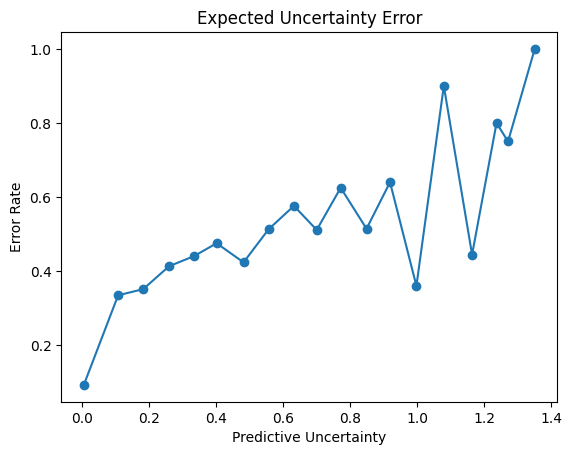

In [8]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_preds != all_labels).astype(float)

n_bins = 20
bins = np.linspace(predictive_uncertainty.min(), predictive_uncertainty.max(), n_bins)
bin_idx = np.digitize(predictive_uncertainty, bins)

bin_uncertainty = []
bin_error = []
for b in range(1, n_bins):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_uncertainty.append(predictive_uncertainty[mask].mean())
        bin_error.append(errors[mask].mean())

unc_min = predictive_uncertainty.min()
unc_max = predictive_uncertainty.max()
unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in bin_uncertainty]
bin_sizes = [((bin_idx == b)).sum() for b in range(1, n_bins) if (bin_idx == b).sum() > 0]

uce = sum(
    s * abs(e - u)
    for s, e, u in zip(bin_sizes, bin_error, unc_normalized)
) / len(all_labels)

print(f'UCE : {100*uce:.2f}%')

plt.plot(bin_uncertainty, bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Expected Uncertainty Error')
plt.show()


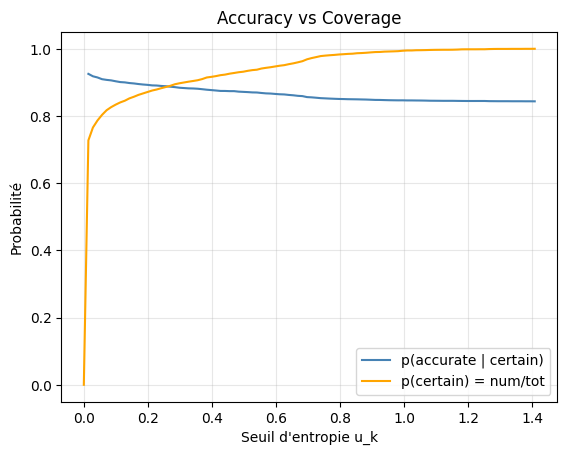

In [9]:
thresholds_h = np.linspace(0, predictive_uncertainty.max(), 100)

p_accurate = []   # courbe décroissante
p_certain  = []   # courbe croissante

for u_k in thresholds_h:
    mask = predictive_uncertainty <= u_k  # prédictions "certaines"
    
    # p(certain) = num/tot
    p_certain.append(mask.sum() / len(all_labels))
    
    # p(accurate|certain)
    if mask.sum() > 0:
        p_accurate.append((all_preds[mask] == all_labels[mask]).mean())
    else:
        p_accurate.append(np.nan)

plt.plot(thresholds_h, p_accurate, label="p(accurate | certain)", color="steelblue")
plt.plot(thresholds_h, p_certain,  label="p(certain) = num/tot",  color="orange")
plt.xlabel("Seuil d'entropie u_k")
plt.ylabel("Probabilité")
plt.title("Accuracy vs Coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Plot la calibration

ECE : 12.32%


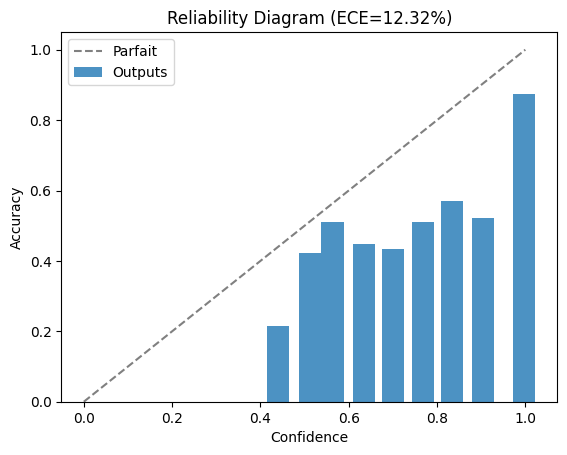

In [10]:
mean_probs = all_outputs.mean(axis=0)
confidences = mean_probs.max(axis=-1)
correct = (all_preds == all_labels).astype(float)

n_bins = 15
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_acc   = []
bin_conf  = []
bin_sizes = []

for i in range(n_bins):
    mask = (confidences >= bin_boundaries[i]) & (confidences < bin_boundaries[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(confidences[mask].mean())
        bin_sizes.append(mask.sum())

ece = sum(s * abs(a - c) for s, a, c in zip(bin_sizes, bin_acc, bin_conf)) / len(all_labels)
print(f'ECE : {100*ece:.2f}%')

plt.bar(bin_conf, bin_acc, width=0.05, alpha=0.8, label='Outputs')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Reliability Diagram (ECE={100*ece:.2f}%)')
plt.legend()
plt.show()

### Adaptive Certainty Error (ACE)

ACE : 12.50%


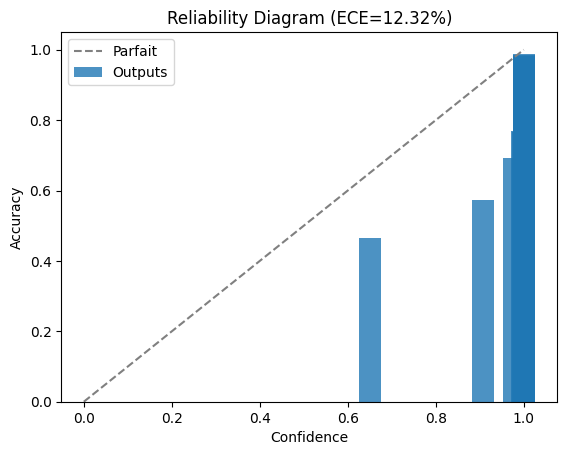

In [ ]:
n_bins = 15
sorted_idx = np.argsort(mean_probs.max(axis=-1))
confidences_sorted = mean_probs.max(axis=-1)[sorted_idx]
correct_sorted = (all_preds == all_labels).astype(float)[sorted_idx]

# Découper en bins de taille égale
bins = np.array_split(np.arange(len(all_labels)), n_bins)

ace_bins_conf = []
ace_bins_acc  = []
ace = 0

for b in bins:
    if len(b) > 0:
        conf = confidences_sorted[b].mean()
        accu  = correct_sorted[b].mean()
        ace_bins_conf.append(conf)
        ace_bins_acc.append(accu)
        ace += len(b) * abs(accu - conf)

ace /= len(all_labels)
print(f'ACE : {100*ace:.2f}%')

plt.bar(ace_bins_conf,  ace_bins_acc, width=0.05, alpha=0.8, label='Outputs')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Reliability Diagram (ECE={100*ece:.2f}%)')
plt.legend()
plt.show()

# Prediction Vector

In [12]:
confidences = all_outputs.mean(axis=0).max(axis=-1)

n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_counts, _ = np.histogram(confidences, bins=bin_edges)
for i in range(n_bins):
    print(f"[{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}] : {bin_counts[i]} images")



[0.0 - 0.1] : 0 images
[0.1 - 0.2] : 0 images
[0.2 - 0.3] : 0 images
[0.3 - 0.4] : 4 images
[0.4 - 0.5] : 25 images
[0.5 - 0.6] : 144 images
[0.6 - 0.7] : 127 images
[0.7 - 0.8] : 133 images
[0.8 - 0.9] : 236 images
[0.9 - 1.0] : 6511 images


### Plot Uncertain when Inaccurate + Confidence vs Accuracy

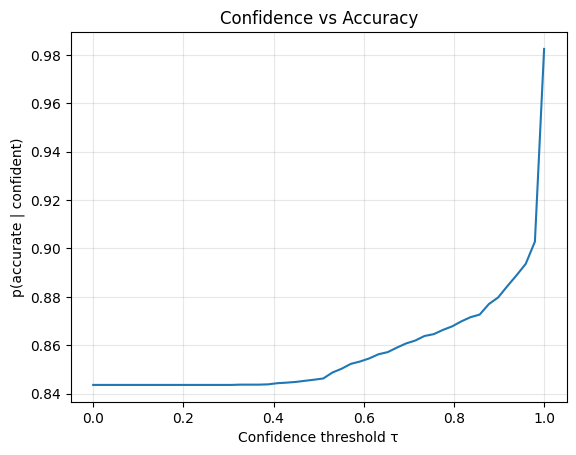

In [13]:
thresholds = np.linspace(0, 1, 50)
p_accurate_given_certain = []

for t in thresholds:
    mask = mean_probs.max(axis=-1) >= t  # prédictions avec confiance >= t
    if mask.sum() > 0:
        p_accurate_given_certain.append((all_preds[mask] == all_labels[mask]).mean())
    else:
        p_accurate_given_certain.append(np.nan)

plt.plot(thresholds, p_accurate_given_certain)
plt.xlabel("Confidence threshold τ")
plt.ylabel("p(accurate | confident)")
plt.title("Confidence vs Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

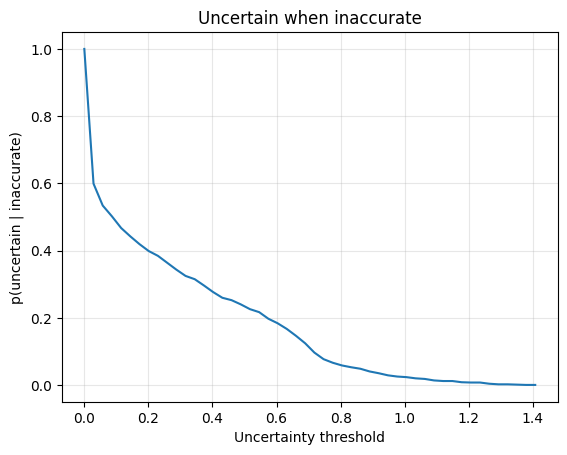

In [14]:
thresholds_u = np.linspace(0, predictive_uncertainty.max(), 50)
p_uncertain_given_inaccurate = []

inaccurate_mask = all_preds != all_labels

for t in thresholds_u:
    if inaccurate_mask.sum() > 0:
        p_uncertain_given_inaccurate.append(
            (predictive_uncertainty[inaccurate_mask] >= t).mean()
        )
    else:
        p_uncertain_given_inaccurate.append(np.nan)

plt.plot(thresholds_u, p_uncertain_given_inaccurate)
plt.xlabel("Uncertainty threshold")
plt.ylabel("p(uncertain | inaccurate)")
plt.title("Uncertain when inaccurate")
plt.grid(True, alpha=0.3)
plt.show()

### Exporte les résultats

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.drawing.image import Image as XLImage
import os
import matplotlib.pyplot as plt
import io

def make_chart_buf(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    plt.close(fig)
    buf.seek(0)
    return buf

def save_results(
    run_type, num_monte_carlo,
    test_acc, val_acc, train_acc, ece, ace, uce,
    bin_uncertainty, bin_error,
    bin_conf, bin_acc, ace_bins_conf, ace_bins_acc, bin_sizes, bin_counts, bin_edges, n_bins,
    conf_thresholds, p_accurate_given_certain,
    threshold_h, p_accurate, p_certain,
    uncertainty_thresholds, p_uncertain_given_inaccurate,
    filename="res.xlsx"
):

    header_font = Font(bold=True, color="FFFFFF", name="Arial")
    header_fill = PatternFill("solid", start_color="2F4F8F")
    normal_font = Font(name="Arial")
    center      = Alignment(horizontal="center")

    def set_header(cell, value):
        cell.value = value
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center

    def set_col_width(ws, col, width):
        ws.column_dimensions[openpyxl.utils.get_column_letter(col)].width = width

    if os.path.exists(filename):
        wb = openpyxl.load_workbook(filename)
    else:
        wb = openpyxl.Workbook()
        wb.active.title = "Runs"

    if "Runs" not in wb.sheetnames:
        ws = wb.create_sheet("Runs", 0)
    else:
        ws = wb["Runs"]

    if ws.cell(1, 1).value is None:
        run_id = 1
    else:
        run_id = ws.max_row

    # Feuille 1 : Runs 
    headers = [
        "Run ID", "Type", "num_monte_carlo"
        "train_acc (%)", "val_acc (%)", "test_acc (%)", "ECE (%)", "ACE (%)", "UCE (%)"
    ]

    if ws.cell(1, 1).value is None:
        for col, h in enumerate(headers, start=1):
            set_header(ws.cell(1, col), h)
        for col in range(1, len(headers) + 1):
            set_col_width(ws, col, 18)

    row = ws.max_row + 1
    values = [
        run_id,
        run_type,
        num_monte_carlo,
        round(100 * train_acc, 2),
        round(100 * val_acc,   2),
        round(100 * test_acc,  2),
        round(100 * ece,       2),
        round(100 * ace,       2),
        round(100 * uce,       2),
    ]
    for col, val in enumerate(values, start=1):
        ws.cell(row, col, val).font = normal_font

    # Feuille 2 : Détails du run
    ws2 = wb.create_sheet(f"Run_{run_id}")

    # EUE
    set_header(ws2.cell(1, 25), "EUE - Uncertainty")
    set_header(ws2.cell(1, 26), "EUE - Error rate")
    set_col_width(ws2, 25, 20); set_col_width(ws2, 26, 20)
    for i, (u, e) in enumerate(zip(bin_uncertainty, bin_error), start=2):
        ws2.cell(i, 25, round(float(u), 4)).font = normal_font
        ws2.cell(i, 26, round(float(e), 4)).font = normal_font

    # ECE
    set_header(ws2.cell(1, 28), "ECE - Confidence")
    set_header(ws2.cell(1, 29), "ECE - Accuracy")
    set_col_width(ws2, 28, 20); set_col_width(ws2, 29, 18)
    for i, (c, a) in enumerate(zip(bin_conf, bin_acc), start=2):
        ws2.cell(i, 28, round(float(c), 4)).font = normal_font
        ws2.cell(i, 29, round(float(a), 4)).font = normal_font

    # ACE
    set_header(ws2.cell(1, 31), "ACE - Confidence")
    set_header(ws2.cell(1, 32), "ACE - Accuracy")
    set_col_width(ws2, 31, 20); set_col_width(ws2, 32, 18)
    for i, (c, a) in enumerate(zip(ace_bins_conf, ace_bins_acc), start=2):
        ws2.cell(i, 31, round(float(c), 4)).font = normal_font
        ws2.cell(i, 32, round(float(a), 4)).font = normal_font
    
    # Confidence vs Accuracy
    set_header(ws2.cell(1, 34), "Conf threshold")
    set_header(ws2.cell(1, 35), "p(accurate|certain)")
    set_col_width(ws2, 34, 18); set_col_width(ws2, 35, 22)
    for i, (t, p) in enumerate(zip(conf_thresholds, p_accurate_given_certain), start=2):
        ws2.cell(i, 34, round(float(t), 4)).font = normal_font
        if not (p != p):
            ws2.cell(i, 35, round(float(p), 4)).font = normal_font

    # Uncertain when inaccurate
    set_header(ws2.cell(1, 37), "Unc threshold")
    set_header(ws2.cell(1, 38), "p(uncertain|inaccurate)")
    set_col_width(ws2, 37, 18); set_col_width(ws2, 38, 24)
    for i, (t, p) in enumerate(zip(uncertainty_thresholds, p_uncertain_given_inaccurate), start=2):
        ws2.cell(i, 37, round(float(t), 4)).font = normal_font
        if not (p != p):
            ws2.cell(i, 38, round(float(p), 4)).font = normal_font

    set_header(ws2.cell(1, 40), "Conf range")
    set_header(ws2.cell(1, 41), "Nb images")
    set_col_width(ws2, 40, 18); set_col_width(ws2, 41, 14)
    for i in range(n_bins):
        label = f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}"
        ws2.cell(i + 2, 40, label).font = normal_font
        ws2.cell(i + 2, 41, int(bin_counts[i])).font = normal_font

    set_header(ws2.cell(1, 42), "Conf range")
    set_header(ws2.cell(1, 43), "Nb images")
    set_header(ws2.cell(1, 44), "Nb images")
    set_col_width(ws2, 42, 18); set_col_width(ws2, 43, 14); set_col_width(ws2, 44, 14)
    for i in range(n_bins):
        label = f"{threshold_h[i]:.1f}-{threshold_h[i+1]:.1f}"
        ws2.cell(i + 2, 42, label).font = normal_font
        ws2.cell(i + 2, 43, round(float(p_accurate[i]), 4)).font = normal_font
        ws2.cell(i + 2, 44, round(float(p_certain[i]), 4)).font = normal_font


    # Graphiques
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([float(u) for u in bin_uncertainty], [float(e) for e in bin_error], marker='o', color="steelblue")
    ax.set_xlabel("Incertitude"); ax.set_ylabel("Taux d'erreur")
    ax.set_title(f"Run {run_id} — EUE"); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "D1"; ws2.add_image(img)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar([float(c) for c in bin_conf], [float(a) for a in bin_acc], width=0.05, alpha=0.8, label="Outputs")
    ax.plot([0,1],[0,1],'--',color='gray',label="Parfait")
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Run {run_id} — ECE ({round(100*ece,2)}%)"); ax.legend(); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "M1"; ws2.add_image(img)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar([float(c) for c in ace_bins_conf], [float(a) for a in ace_bins_acc], width=0.05, alpha=0.8, label="Outputs")
    ax.plot([0,1],[0,1],'--',color='gray',label="Parfait")
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Run {run_id} — ACE ({round(100*ace,2)}%)"); ax.legend(); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "D50"; ws2.add_image(img)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(conf_thresholds, p_accurate_given_certain, color="steelblue")
    ax.set_xlabel("Confidence threshold"); ax.set_ylabel("p(accurate|certain)")
    ax.set_title(f"Run {run_id} — Confidence vs Accuracy"); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "D25"; ws2.add_image(img)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(uncertainty_thresholds, p_uncertain_given_inaccurate, color="orange")
    ax.set_xlabel("Uncertainty threshold"); ax.set_ylabel("p(uncertain|inaccurate)")
    ax.set_title(f"Run {run_id} — Uncertain when inaccurate"); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "M25"; ws2.add_image(img)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(threshold_h, p_accurate, label="p(accurate | certain)", color="steelblue")
    ax.plot(threshold_h, p_certain,  label="p(certain) = num/tot",  color="orange")
    ax.set_xlabel("entropie u_k"); ax.set_ylabel("probability")
    ax.set_title(f"Run {run_id} — Accuracy vs Coverage"); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "M50"; ws2.add_image(img)

    wb.save(filename)
    print(f"Run {run_id} sauvegardé dans : {filename}")
    

# Appel
save_results(
    run_type = "EffBayNoMopedLiz",
    num_monte_carlo=num_monte_carlo,
    test_acc=test_acc,
    val_acc=val_acc,
    train_acc=train_acc,
    ece=ece,
    ace=ace,
    uce=uce,
    bin_uncertainty=bin_uncertainty,
    bin_error=bin_error,
    bin_conf=bin_conf,
    bin_acc=bin_acc,
    ace_bins_conf=ace_bins_conf,
    ace_bins_acc = ace_bins_acc,
    bin_sizes=bin_sizes,
    bin_counts=bin_counts,
    bin_edges=bin_edges,
    n_bins=n_bins,
    conf_thresholds=thresholds,
    p_accurate_given_certain=p_accurate_given_certain,
    threshold_h = thresholds_h, 
    p_accurate = p_accurate, 
    p_certain = p_certain,
    uncertainty_thresholds=thresholds_u,
    p_uncertain_given_inaccurate=p_uncertain_given_inaccurate,
    filename="res.xlsx"
)

Run 5 sauvegardé dans : res.xlsx
